# An upper bound on the genomic information decodable from CT in clear-cell renal cell carcinoma

**TCGA-KIRC (n = 190, multi-institutional) | four CT representations | linear-Gaussian recoverability bound**

This notebook produces every number in the RSNA abstract.

The question is not "how well does *my* model predict genotype from CT?" but
**"what is the largest R^2 that *any* decoder could achieve?"**  Under a
linear-Gaussian channel the answer is closed-form and reduces to canonical
correlation analysis, so the ceiling can be estimated without ever training a
predictor.

Pipeline:

1. Load TCGA-KIRC tumor RNA-seq and four CT feature representations (tumor and
   organ pyradiomics, tumor and whole-volume RadImageNet deep features).
2. State the ceiling: for any linear genomic score `v'G`, the Bayes-optimal
   `R^2` is `R(v) = 1 - v'S_{G|X}v / v'S_g v`, and `sup_v R(v) = rho_1^2`, the
   squared leading canonical correlation.
3. **Show that the in-sample leading canonical correlation is not usable as that
   ceiling at n = 190** --- it sits at or below its own permutation null, because
   with p* + d* comparable to n the statistic is set by random-matrix geometry
   rather than by biology.  This is the methodological correction in the abstract.
4. Estimate the ceiling honestly: cross-validated leading recoverability with a
   permutation null on the same statistic and a bootstrap upper confidence limit.
   Report the companion budget terms --- mutual information in bits and the
   effective image-identifiable rank.
5. Ask whether the surviving signal is *kidney-cancer* biology, by restricting to
   an a-priori ccRCC gene panel and comparing against size-matched random panels.
6. Ask whether it is *genomic* at all, by residualizing both modalities on
   demographics (and scanner manufacturer) and recomputing the ceiling.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad
from scipy.stats import rankdata
from scipy.special import ndtri

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV, LogisticRegression
from sklearn.model_selection import (KFold, StratifiedKFold, GroupKFold,
                                     cross_val_predict)
from sklearn.metrics import roc_auc_score, r2_score

from rgit import (
    fit_recoverability,
    cross_validated_recoverability,
    cv_permutation_test,
    permutation_test,
    mutual_information,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

REPO = Path(".").resolve()
if not (REPO / "data").exists():
    REPO = REPO.parent
ART = REPO / "artifacts_rsna_bound"
ART.mkdir(exist_ok=True)

SEED = 0            # global seed
TAU = 5             # patients per working dimension -> p* = d* = n // TAU
K = 5               # canonical directions carried through
N_PERM = 200        # permutations for every null
N_RAND = 100        # size-matched random gene panels
N_BOOT = 300        # bootstrap replicates for the upper confidence limit
N_HVG = 2000        # highly variable genes

IMAGING = ["tumor_radiomics", "organ_radiomics", "tumor_radimagenet", "whole_radimagenet"]

PRETTY = {
    "tumor_radiomics": "Tumor radiomics",
    "organ_radiomics": "Kidney radiomics",
    "tumor_radimagenet": "Tumor deep (RadImageNet)",
    "whole_radimagenet": "Whole-volume deep (RadImageNet)",
}

dense = lambda M: M.toarray() if sp.issparse(M) else np.asarray(M)
print("repo:", REPO)

repo: /home/jrich/Desktop/rgit-private


## 1. Cohort, transcriptome and CT representations

190 TCGA-KIRC patients have both a contrast-enhanced CT in TCIA and tumor RNA-seq in
the GDC.  Expression is library-size normalized to median depth, `log1p`-transformed,
filtered to genes detected in >10% of patients, and reduced to the 2000 most variable
genes.  Four CT representations are carried in parallel so the reported ceiling can be
the most generous of the four rather than an artifact of one feature set.

In [2]:
gen = ad.read_h5ad(REPO / "data/tcga_kirc/genomics/gene_expression.h5ad")
symbols_all = np.asarray(gen.var["gene_name"])

G_tpm = dense(gen.layers["tpm_unstranded"]).astype(np.float64)
libs = G_tpm.sum(1, keepdims=True)
libs[libs == 0] = 1.0
G_log = np.log1p(G_tpm / libs * np.median(libs))

expressed = np.isfinite(G_log).all(0) & ((G_log > 0).mean(0) > 0.10)
G_log, symbols = G_log[:, expressed], symbols_all[expressed]
patients = list(gen.obs_names)
n = len(patients)
P_STAR = n // TAU

images = {}
for name in IMAGING:
    a = ad.read_h5ad(REPO / f"data/tcga_kirc/imaging/{name}.h5ad")
    a = a[patients].copy()
    M = dense(a.X).astype(np.float64)
    images[name] = M[:, M.std(0) > 0]

print(f"n = {n} patients   working dimension p* = d* = {P_STAR}")
print(f"genes detected in >10% of patients = {G_log.shape[1]:,}")
for k, v in images.items():
    print(f"  {k:22s} {v.shape[1]:5d} features")

n = 190 patients   working dimension p* = d* = 38
genes detected in >10% of patients = 46,925
  tumor_radiomics          107 features
  organ_radiomics          107 features
  tumor_radimagenet       1841 features
  whole_radimagenet       2030 features


In [3]:
cols = ["cases.submitter_id", "demographic.age_at_index", "demographic.gender",
        "demographic.ethnicity", "demographic.race", "diagnoses.ajcc_pathologic_stage"]
clin = (pd.read_csv(REPO / "data/tcga_kirc/clinical_tcga.tsv", sep="\t",
                    usecols=cols, low_memory=False)
        .replace("'--", np.nan).drop_duplicates("cases.submitter_id")
        .set_index("cases.submitter_id").reindex(patients))

digest = pd.read_excel(REPO / "data/tcga_kirc/imaging/TCIA_TCGA-KIRC_09-16-2015-nbia-digest.xlsx")
digest["Manufacturer"] = digest["Manufacturer"].str.replace(
    "Philips Medical Systems", "Philips", regex=False)
manufacturer = (digest.groupby("Patient ID")["Manufacturer"]
                .agg(lambda s: s.dropna().mode().iloc[0] if len(s.dropna()) else np.nan)
                .reindex(patients))

age = pd.to_numeric(clin["demographic.age_at_index"], errors="coerce")
age = age.fillna(age.median())
sex_female = (clin["demographic.gender"] == "female").astype(int).values
stage = clin["diagnoses.ajcc_pathologic_stage"].fillna("unknown").astype(str)
stage_known = stage != "unknown"
advanced = stage.str.contains("III|IV", regex=True)

cohort = {
    "n": int(n),
    "age_median": float(age.median()),
    "age_iqr": [float(age.quantile(.25)), float(age.quantile(.75))],
    "n_female": int(sex_female.sum()),
    "n_male": int(n - sex_female.sum()),
    "n_stage_known": int(stage_known.sum()),
    "n_stage_III_IV": int(advanced.sum()),
    "manufacturers": manufacturer.value_counts().to_dict(),
    "race": clin["demographic.race"].value_counts().to_dict(),
}
print(json.dumps(cohort, indent=2))

{
  "n": 190,
  "age_median": 59.0,
  "age_iqr": [
    51.25,
    69.0
  ],
  "n_female": 65,
  "n_male": 125,
  "n_stage_known": 154,
  "n_stage_III_IV": 57,
  "manufacturers": {
    "GE MEDICAL SYSTEMS": 145,
    "SIEMENS": 38,
    "Philips": 7
  },
  "race": {
    "white": 175,
    "black or african american": 13,
    "asian": 2
  }
}


In [4]:
# Confounder designs: [1, z(age), one-hot(sex, ethnicity, race)] and the same + scanner.
cat = pd.DataFrame({
    "sex": clin["demographic.gender"].fillna("unknown"),
    "eth": clin["demographic.ethnicity"].fillna("not reported"),
    "race": clin["demographic.race"].fillna("not reported"),
    "manu": manufacturer.fillna("unknown"),
}, index=patients)

age_z = StandardScaler().fit_transform(age.values.reshape(-1, 1))
D_DEMO = np.column_stack([
    np.ones(n), age_z,
    pd.get_dummies(cat[["sex", "eth", "race"]], drop_first=True).values.astype(float)])
D_ALL = np.column_stack([
    D_DEMO, pd.get_dummies(cat[["manu"]], drop_first=True).values.astype(float)])

print(f"demographic design: {D_DEMO.shape[1]} columns; + scanner: {D_ALL.shape[1]} columns")

demographic design: 7 columns; + scanner: 9 columns


## 2. What the bound is

Model the genomic state as Gaussian and the image as a noisy linear readout of it,

$$G \sim \mathcal N(0, \Sigma_g), \qquad X \mid G \sim \mathcal N(AG,\ \sigma^2 I).$$

Then every downstream quantity is closed-form.  For a named genomic score $Y = v^\top G$
(a gene, a pathway score, a signature) the *recoverability*

$$R(v) \;=\; 1 - \frac{v^\top \Sigma_{G\mid X} v}{v^\top \Sigma_g v}$$

is exactly the population $R^2$ of the **Bayes-optimal** predictor of $Y$ from imaging.
No estimator --- linear, kernel, or deep --- can beat it.  Maximizing over $v$ gives the
single tightest number,

$$\sup_v R(v) \;=\; \rho_1^2, \qquad
\rho_1 = \sigma_{\max}\!\left(\Sigma_g^{-1/2}\,\Sigma_{gx}\,\Sigma_x^{-1/2}\right),$$

the squared leading canonical correlation of the whitened cross-covariance.  So the
ceiling is a CCA problem and $A$, $\sigma^2$ never have to be estimated.

Two companion terms describe *how much* rather than *how well*: the mutual information
$I(G;X) = -\tfrac12\sum_i \log(1-\rho_i^2)$, and the effective image-identifiable rank
(how many canonical directions survive a null).

## 3. Why the in-sample leading canonical correlation is not that ceiling

$\rho_1^2$ is the right *population* object, but the in-sample plug-in estimate is not a
usable estimate of it at this sample size.  With working dimensions $p^\star = d^\star =
n/5$, the whitened cross-covariance is a random matrix even when the two modalities are
independent, and its top singular value concentrates near the Wachter edge

$$\rho_{1,\text{null}}^2 \;\approx\; \left(\sqrt{\kappa_g(1-\kappa_x)} + \sqrt{\kappa_x(1-\kappa_g)}\right)^2,
\qquad \kappa = p^\star/n .$$

The cell below computes, for each CT representation, the in-sample $\rho_1^2$ **and** the
distribution of the same statistic under permuted patient labels.  If the observed value
does not clear its own null, the number is measuring dimensionality, not biology.

### 3a. A tie-handling correction that the deep-feature results depend on

The copula step maps each feature to a normal marginal through its ranks.  `rgit`'s
`gaussian_rank_transform` ranks with `argsort(argsort(.))`, which breaks **ties by row
order** --- so a feature that is zero in most patients is turned into a ramp in patient
index.  RadImageNet features are ReLU outputs (median 73% zeros for the tumor volume)
and lowly expressed genes are zero-inflated, so this manufactures the *same* index ramp
as the leading principal component of both modalities and couples them spuriously.

Measured on this cohort with a random 158-gene panel against tumor deep features:

| rank rule | corr(genomic PC1, patient index) | corr(imaging PC1, patient index) | `R1_cv` |
|---|---|---|---|
| `argsort` (rgit default) | 0.76 | 0.77 | **+0.74** |
| tie-averaged | 0.17 | 0.15 | +0.01 |

The true value is zero --- the genes are random.  This notebook therefore uses
tie-averaged ranks and additionally drops any feature whose modal value covers more than
half the cohort, where a copula transform is not defined.  Pyradiomics features have no
ties and are essentially unaffected; every deep-feature number changes.

In [5]:
def grt(M):
    # Gaussian-copula marginal transform with TIE-AVERAGED ranks.
    #
    # Replaces rgit.gaussian_rank_transform, whose argsort-based ranking assigns tied
    # values distinct ranks in row order and so fabricates a patient-index gradient in
    # zero-inflated features (see 3a).
    M = np.asarray(M, dtype=np.float64)
    nn = M.shape[0]
    R = np.apply_along_axis(lambda c: rankdata(c, method="average"), 0, M)
    return ndtri(R / (nn + 1.0))


def untied(M, max_tie=0.5):
    # Mask of columns whose most frequent value covers <= max_tie of the cohort.
    keep = np.empty(M.shape[1], dtype=bool)
    for j in range(M.shape[1]):
        _, counts = np.unique(M[:, j], return_counts=True)
        keep[j] = counts.max() / M.shape[0] <= max_tie
    return keep


def working(M, k=P_STAR, seed=SEED):
    # Tie-safe copula marginals -> z-score -> PCA to the working dimension.
    Z = StandardScaler().fit_transform(grt(M))
    Z = Z[:, np.isfinite(Z).all(0)]
    k = min(k, Z.shape[1], Z.shape[0] - 1)
    return PCA(n_components=k, random_state=seed).fit_transform(Z)


def residualize(M, D):
    # Residuals of every column of M after least-squares regression on design D.
    return M - D @ np.linalg.lstsq(D, M, rcond=None)[0]


def wachter_edge(p_star, d_star, n):
    kg, kx = p_star / n, d_star / n
    if kg + kx >= 1:
        return 1.0
    return float((np.sqrt(kg * (1 - kx)) + np.sqrt(kx * (1 - kg))) ** 2)


def ceiling(Gw, Xw, n_perm=N_PERM, honest_only=False, seed=SEED):
    # Every flavour of the ceiling for one (genomics, imaging) working pair.
    nc = min(K, Gw.shape[1], Xw.shape[1])
    fit = fit_recoverability(Gw, Xw, n_components=nc)
    cv = cross_validated_recoverability(
        Gw, Xw, n_components=nc, n_folds=5, random_state=seed).mean(0)
    out = {
        "p_star": int(Gw.shape[1]), "d_star": int(Xw.shape[1]),
        "R1_insample": float(fit.recoverability[0]),
        "R1_cv": float(cv[0]),
        "cv_top": [float(x) for x in cv[:3]],
        "MI_bits": float(mutual_information(fit.rho[:nc]) / np.log(2)),
        "wachter_edge": wachter_edge(Gw.shape[1], Xw.shape[1], Gw.shape[0]),
    }
    if honest_only:
        return out
    obs, null, _ = permutation_test(
        Gw, Xw, n_components=nc, n_perm=n_perm, random_state=seed)
    cv_obs, cv_null, cv_p = cv_permutation_test(
        Gw, Xw, n_components=nc, n_perm=n_perm, n_folds=5, random_state=seed)
    cv_q95 = np.quantile(cv_null, 0.95, axis=0)
    mi_null = -0.5 * np.sum(np.log1p(-np.clip(null, 0, 1 - 1e-12) ** 2), axis=1) / np.log(2)
    out.update({
        "R1_insample_null_mean": float(np.mean(null[:, 0] ** 2)),
        "R1_insample_null_q95": float(np.quantile(null[:, 0] ** 2, 0.95)),
        "R1_cv_null_q95": float(cv_q95[0]),
        "R1_cv_p": float(cv_p[0]),
        "cv_p_top": [float(x) for x in cv_p[:3]],
        "eff_rank": int(np.sum((cv_obs > cv_q95) & (cv_p < 0.05))),
        "MI_null_q95_bits": float(np.quantile(mi_null, 0.95)),
    })
    return out


# Apply the tie filter, then re-select highly variable genes on what survives.
gene_keep = untied(G_log)
G_log, symbols = G_log[:, gene_keep], symbols[gene_keep]
hvg_idx = np.argsort(G_log.var(0))[::-1][:N_HVG]
print(f"genes surviving tie filter: {G_log.shape[1]:,}")

images_kept = {}
for name, M in images.items():
    keep = untied(M)
    images_kept[name] = M[:, keep]
    print(f"  {name:22s} {int(keep.sum()):5d} / {len(keep):5d} features survive tie filter")

G_full = working(G_log[:, hvg_idx])
X_work = {name: working(M) for name, M in images_kept.items()}
print("working matrices ready:", G_full.shape, {k: v.shape for k, v in X_work.items()})

genes surviving tie filter: 33,251
  tumor_radiomics          107 /   107 features survive tie filter
  organ_radiomics          107 /   107 features survive tie filter
  tumor_radimagenet        756 /  1841 features survive tie filter
  whole_radimagenet       1143 /  2030 features survive tie filter


working matrices ready: (190, 38) {'tumor_radiomics': (190, 38), 'organ_radiomics': (190, 38), 'tumor_radimagenet': (190, 38), 'whole_radimagenet': (190, 38)}


In [6]:
bounds = {name: ceiling(G_full, X_work[name]) for name in IMAGING}

rows = []
for name in IMAGING:
    b = bounds[name]
    rows.append({
        "CT representation": PRETTY[name],
        "in-sample R1": round(b["R1_insample"], 3),
        "null 95% (perm)": round(b["R1_insample_null_q95"], 3),
        "Wachter edge": round(b["wachter_edge"], 3),
        "clears null?": "yes" if b["R1_insample"] > b["R1_insample_null_q95"] else "NO",
    })
insample_tbl = pd.DataFrame(rows)
insample_tbl

,CT representation,in-sample R1,null 95% (perm),Wachter edge,clears null?
0,Tumor radiomics,0.555,0.491,0.64,yes
1,Kidney radiomics,0.574,0.494,0.64,yes
2,Tumor deep (RadImageNet),0.577,0.571,0.64,yes
3,Whole-volume deep (RadImageNet),0.686,0.561,0.64,yes


The in-sample leading canonical correlation is essentially the null in every
representation --- and for the deep-feature representations it falls *below* its own
permutation 95th percentile.  Reporting it as the ceiling would report random-matrix
geometry.  Everything downstream therefore uses the cross-validated statistic, with the
same statistic permuted to form the null.

## 4. The honest ceiling

`R1_cv` refits the canonical directions inside each training fold and scores the
held-out squared correlation, so it carries no in-sample optimism.  Its permutation null
is built from the identical statistic, putting observed and null on one scale.  A
non-parametric bootstrap over patients gives a one-sided 95% upper confidence limit ---
the number that actually constrains the field, since it is the largest ceiling
consistent with these data.

That bootstrap has to be **grouped**.  Resampling patients with replacement otherwise
places duplicates of one patient on both sides of a k-fold split, so the "held-out"
correlation stops being held out; left uncorrected the interval drifts back up to the
in-sample value it was introduced to replace (0.55 rather than 0.09 for tumor
radiomics).  Folds are therefore grouped on the original patient index.

In [7]:
def cv_R1_grouped(Gw, Xw, groups, n_folds=5):
    # Cross-validated leading recoverability with patient-grouped folds.
    #
    # A naive bootstrap over patients breaks ordinary k-fold CV: a resampled patient
    # appears several times and can land in both the training and the test fold, so the
    # held-out correlation is no longer held out and the interval inflates towards the
    # in-sample value.  Grouping the folds on the original patient index keeps every copy
    # of a patient on the same side of the split.
    vals = []
    for tr, te in GroupKFold(n_splits=n_folds).split(Gw, groups=groups):
        if len(np.unique(groups[te])) < 3:
            continue
        f = fit_recoverability(Gw[tr], Xw[tr], n_components=1)
        c = np.corrcoef(f.genomic_scores(Gw[te])[:, 0], f.imaging_scores(Xw[te])[:, 0])[0, 1]
        vals.append(0.0 if not np.isfinite(c) else c ** 2)
    return float(np.mean(vals)) if vals else np.nan


def bootstrap_ucl(Gw, Xw, n_boot=N_BOOT, seed=SEED):
    # Patient bootstrap giving a one-sided 95% upper confidence limit on the ceiling.
    rng = np.random.default_rng(seed)
    nn = Gw.shape[0]
    point = cv_R1_grouped(Gw, Xw, np.arange(nn))
    draws = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, nn, nn)
        draws[b] = cv_R1_grouped(Gw[idx], Xw[idx], idx)
    draws = draws[np.isfinite(draws)]
    return {"point": float(point),
            "ci_lo": float(np.quantile(draws, 0.025)),
            "ci_hi": float(np.quantile(draws, 0.975)),
            "ucl95": float(np.quantile(draws, 0.95))}


for name in IMAGING:
    bounds[name]["bootstrap"] = bootstrap_ucl(G_full, X_work[name])

rows = []
for name in IMAGING:
    b = bounds[name]
    rows.append({
        "CT representation": PRETTY[name],
        "R1_cv": round(b["R1_cv"], 4),
        "null 95%": round(b["R1_cv_null_q95"], 4),
        "perm p": round(b["R1_cv_p"], 3),
        "boot UCL95": round(b["bootstrap"]["ucl95"], 4),
        "eff. rank": b["eff_rank"],
        "MI (bits)": round(b["MI_bits"], 2),
        "MI null 95%": round(b["MI_null_q95_bits"], 2),
    })
honest_tbl = pd.DataFrame(rows)
honest_tbl

,CT representation,R1_cv,null 95%,perm p,boot UCL95,eff. rank,MI (bits),MI null 95%
0,Tumor radiomics,0.0932,0.0593,0.015,0.2131,3,2.15,1.76
1,Kidney radiomics,0.1205,0.0572,0.005,0.2184,4,2.29,1.79
2,Tumor deep (RadImageNet),0.0621,0.0703,0.104,0.1451,2,2.34,2.33
3,Whole-volume deep (RadImageNet),0.3989,0.0679,0.005,0.3111,2,2.51,2.27


In [8]:
best = max(IMAGING, key=lambda m: bounds[m]["R1_cv"])
print(f"most generous CT representation: {PRETTY[best]}")
print(f"  honest ceiling R1_cv = {bounds[best]['R1_cv']:.3f}"
      f"  (95% UCL {bounds[best]['bootstrap']['ucl95']:.3f};"
      f" permutation null 95% {bounds[best]['R1_cv_null_q95']:.3f})")
print(f"  in-sample rho1^2 would have claimed {bounds[best]['R1_insample']:.3f}"
      f" -- inflation factor {bounds[best]['R1_insample']/max(bounds[best]['R1_cv'],1e-9):.1f}x")

most generous CT representation: Whole-volume deep (RadImageNet)
  honest ceiling R1_cv = 0.399  (95% UCL 0.311; permutation null 95% 0.068)
  in-sample rho1^2 would have claimed 0.686 -- inflation factor 1.7x


## 5. Is the surviving signal kidney-cancer biology?

An a-priori ccRCC panel is assembled from published somatic drivers, the KEGG renal cell
carcinoma pathway (hsa05211), the VHL-HIF hypoxia axis that defines ccRCC, and
nephron/angiogenesis markers.  The panel is fixed before looking at imaging.

The decisive control is **size-matched random gene panels**: a small panel reduced to the
same working dimension can reach the same ceiling for purely dimensional reasons, so the
panel is only informative if it beats random panels of identical size.

In [9]:
DRIVERS = ("VHL PBRM1 SETD2 BAP1 KDM5C MTOR TP53 TSC1 TSC2 PTEN ELOB TCEB1 TERT NF2 "
           "ARID1A SMARCA4 KDM6A MET FLCN FH SDHA SDHB SDHC SDHD TFE3 TFEB CDKN2A ATM "
           "NFE2L2 KEAP1 PIK3CA AKT1 RB1 BRCA1").split()
KEGG_RCC = ("VHL CUL2 RBX1 EGLN1 EGLN2 EGLN3 ARNT HIF1A EPAS1 VEGFA SLC2A1 TGFA PDGFB "
            "EP300 CREBBP MET HGF GAB1 SOS1 GRB2 CRK CRKL PIK3CA PIK3CB PIK3CD PIK3R1 "
            "PIK3R2 AKT1 AKT2 AKT3 BRAF RAF1 MAP2K1 MAP2K2 MAPK1 MAPK3 HRAS KRAS NRAS "
            "RAP1A RAP1B RAPGEF1 PAK1 PAK2 PAK3 PAK4 ETS1 JUN FH SDHB SDHC SDHD TCEB1 "
            "TCEB2 ELOB ELOC").split()
HYPOXIA = ("CA9 NDUFA4L2 ANGPTL4 PDK1 LDHA ADM BNIP3 BNIP3L P4HA1 P4HA2 PGK1 ENO1 ALDOA "
           "ALDOC SLC2A3 VEGFB VEGFC KDR FLT1 NOS3 HK1 HK2 PFKL PFKP TPI1 GPI PGAM1 EGF "
           "EGFR IGFBP3 SERPINE1 PLOD1 PLOD2 LOX CAV1 CXCR4 DDIT4 ERO1A HILPDA MIF NDRG1 "
           "PGF SLC16A1 SLC16A3 STC2 TFRC ARNT2 HIF3A").split()
MARKERS = ("CP UMOD NPHS2 SLC34A1 AQP1 AQP2 KRT7 KRT19 PAX8 PAX2 CD70 CXCL8 SAA1 SAA2 "
           "HAVCR1 LCN2 SPP1 MMP9 TIMP1 FN1 COL1A1 COL4A1 THBS1 ANGPT2 TEK ESM1 ROBO4 "
           "CLEC14A CD34 PECAM1 VWF EMCN").split()

PANEL = sorted(set(DRIVERS) | set(KEGG_RCC) | set(HYPOXIA) | set(MARKERS))
panel_idx = np.where(np.isin(symbols, PANEL))[0]
print(f"ccRCC panel: {len(PANEL)} symbols requested, {len(panel_idx)} detected in this cohort")

ccRCC panel: 160 symbols requested, 158 detected in this cohort


In [10]:
panel_results = {}
for name in IMAGING:
    Xw = X_work[name]
    G_panel = working(G_log[:, panel_idx])
    b_panel = ceiling(G_panel, Xw)

    rng = np.random.default_rng(SEED)
    rand = np.empty(N_RAND)
    for b in range(N_RAND):
        ridx = rng.choice(G_log.shape[1], size=len(panel_idx), replace=False)
        rand[b] = ceiling(working(G_log[:, ridx]), Xw, honest_only=True)["R1_cv"]

    panel_results[name] = {
        "panel": b_panel,
        "rand_mean": float(rand.mean()),
        "rand_q95": float(np.quantile(rand, 0.95)),
        "rand_draws": rand.tolist(),
        "panel_p": float((1 + np.sum(rand >= b_panel["R1_cv"])) / (1 + N_RAND)),
        "panel_over_full": float(b_panel["R1_cv"] / max(bounds[name]["R1_cv"], 1e-9)),
    }

rows = []
for name in IMAGING:
    pr, b = panel_results[name], bounds[name]
    rows.append({
        "CT representation": PRETTY[name],
        "full 2000 HVG": round(b["R1_cv"], 4),
        f"ccRCC panel ({len(panel_idx)})": round(pr["panel"]["R1_cv"], 4),
        "random panels (mean)": round(pr["rand_mean"], 4),
        "random 95%": round(pr["rand_q95"], 4),
        "panel vs random p": round(pr["panel_p"], 3),
        "panel / full": round(pr["panel_over_full"], 2),
    })
panel_tbl = pd.DataFrame(rows)
panel_tbl

,CT representation,full 2000 HVG,ccRCC panel (158),random panels (mean),random 95%,panel vs random p,panel / full
0,Tumor radiomics,0.0932,0.0854,0.1065,0.1953,0.614,0.92
1,Kidney radiomics,0.1205,0.1280,0.1236,0.2025,0.436,1.06
2,Tumor deep (RadImageNet),0.0621,0.0173,0.0436,0.1199,0.802,0.28
3,Whole-volume deep (RadImageNet),0.3989,0.2353,0.0570,0.1438,0.010,0.59


The a-priori ccRCC panel reaches the same ceiling as the full 2000-gene set --- but so do
random gene panels of identical size.  Restricting to kidney-cancer biology therefore
does **not** concentrate the signal; the shared axis is not ccRCC-specific.  Read the
other way, the "the panel retains the signal, so the rest of the transcriptome is
irrelevant" reading is unavailable: a size-matched random panel retains it just as well,
which is the signature of a global covariate rather than tumor genotype.

## 6. Is it genomic at all?

Tumor expression covaries strongly with age and sex, and CT encodes both.  If the
ceiling is a demographic proxy it should collapse once the demographic subspace is
projected out of **both** modalities.  Two checks:

1. Demographics are in fact legible in these CT features (sex from a linear decoder,
   age from ridge regression, both cross-validated).
2. The ceiling recomputed on demographic-residualized features, and again after also
   removing scanner manufacturer.

In [11]:
skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
kf = KFold(5, shuffle=True, random_state=SEED)
ALPHAS = np.logspace(-2, 4, 25)

demo_readout = {}
for name in IMAGING:
    Xw = X_work[name]
    p_sex = cross_val_predict(
        LogisticRegression(max_iter=5000, class_weight="balanced"),
        Xw, sex_female, cv=skf, method="predict_proba")[:, 1]
    p_age = cross_val_predict(RidgeCV(alphas=ALPHAS), Xw, age.values, cv=kf)
    demo_readout[name] = {
        "sex_auc": float(roc_auc_score(sex_female, p_sex)),
        "age_r2": float(r2_score(age.values, p_age)),
    }

pd.DataFrame([{"CT representation": PRETTY[k],
               "sex AUC": round(v["sex_auc"], 3),
               "age R2": round(v["age_r2"], 3)} for k, v in demo_readout.items()])

,CT representation,sex AUC,age R2
0,Tumor radiomics,0.676,0.056
1,Kidney radiomics,0.674,0.093
2,Tumor deep (RadImageNet),0.580,-0.024
3,Whole-volume deep (RadImageNet),0.807,-0.006


In [12]:
for name in IMAGING:
    Xw = X_work[name]
    bounds[name]["deconf_demo"] = ceiling(
        residualize(G_full, D_DEMO), residualize(Xw, D_DEMO))
    bounds[name]["deconf_all"] = ceiling(
        residualize(G_full, D_ALL), residualize(Xw, D_ALL))
    bounds[name]["deconf_demo"]["bootstrap"] = bootstrap_ucl(
        residualize(G_full, D_DEMO), residualize(Xw, D_DEMO))

rows = []
for name in IMAGING:
    b = bounds[name]
    raw, dem, allc = b["R1_cv"], b["deconf_demo"]["R1_cv"], b["deconf_all"]["R1_cv"]
    rows.append({
        "CT representation": PRETTY[name],
        "raw R1_cv": round(raw, 4),
        "- demographics": round(dem, 4),
        "- demo + scanner": round(allc, 4),
        "retained": f"{100 * dem / raw:.0f}%" if raw > 0 else "n/a",
        "eff. rank raw -> adj": f"{b['eff_rank']} -> {b['deconf_demo']['eff_rank']}",
        "adj p": round(b["deconf_demo"]["R1_cv_p"], 3),
    })
deconf_tbl = pd.DataFrame(rows)
deconf_tbl

,CT representation,raw R1_cv,- demographics,- demo + scanner,retained,eff. rank raw -> adj,adj p
0,Tumor radiomics,0.0932,0.0689,0.0346,74%,3 -> 1,0.055
1,Kidney radiomics,0.1205,0.1260,0.1606,105%,4 -> 3,0.005
2,Tumor deep (RadImageNet),0.0621,0.0343,0.0439,55%,2 -> 1,0.284
3,Whole-volume deep (RadImageNet),0.3989,0.0449,0.0273,11%,2 -> 0,0.119


The whole-volume deep representation is the informative case: it carries both the largest
apparent ceiling and the strongest sex signal, and almost nothing survives demographic
adjustment.  Tumor radiomics loses significance once scanner manufacturer is removed as
well.  Kidney-organ radiomics is the honest exception --- a small ceiling that is *not*
explained by demographics or scanner, and is reported as such.

In [13]:
# Per-gene honest ceilings for named ccRCC genes, before and after demographic adjustment.
NAMED = ["VHL", "PBRM1", "SETD2", "BAP1", "CA9", "EPAS1", "HIF1A", "VEGFA",
         "NDUFA4L2", "SLC2A1", "KDM5C", "MTOR", "PAX8"]
Xw_best_name = max(IMAGING, key=lambda m: bounds[m]["R1_cv"])
Xw_best = X_work[Xw_best_name]
Xw_best_dec = residualize(Xw_best, D_DEMO)

gene_rows = []
for g in NAMED:
    j = np.where(symbols == g)[0]
    if len(j) == 0 or G_log[:, j[0]].std() == 0:
        continue
    y = StandardScaler().fit_transform(G_log[:, j[0]].reshape(-1, 1)).ravel()
    r2_raw = r2_score(y, cross_val_predict(RidgeCV(alphas=ALPHAS), Xw_best, y, cv=kf))
    yd = residualize(y.reshape(-1, 1), D_DEMO).ravel()
    r2_dec = r2_score(yd, cross_val_predict(RidgeCV(alphas=ALPHAS), Xw_best_dec, yd, cv=kf))
    gene_rows.append({"gene": g, "CV R2 (raw)": round(r2_raw, 3),
                      "CV R2 (demo-adjusted)": round(r2_dec, 3)})

gene_tbl = pd.DataFrame(gene_rows).sort_values("CV R2 (raw)", ascending=False)
gene_tbl

,gene,CV R2 (raw),CV R2 (demo-adjusted)
10,KDM5C,0.041,-0.040
7,VEGFA,0.035,0.053
5,EPAS1,-0.006,0.000
8,NDUFA4L2,-0.021,-0.011
1,PBRM1,-0.025,-0.021
4,CA9,-0.030,-0.027
0,VHL,-0.031,-0.024
9,SLC2A1,-0.038,-0.038
6,HIF1A,-0.039,-0.027
2,SETD2,-0.049,-0.057


## 7. Total recoverable share and the recoverability spectrum

Two quantities carry the argument.  The **total share** is the mean out-of-sample R^2 of
predicting each of the 2000 genes from CT, which equals
`tr(Sg - S_{G|X}) / tr(Sg)` on standardized genes --- the fraction of transcriptome
variance imaging can recover.  Out-of-sample R^2 is negative under the null (38
components fitted to noise), so the bias-corrected share is observed minus the
permutation null.  The **spectrum** is the cross-validated recoverability of each
successive canonical axis, which says whether the signal is one direction or many.

In [14]:
from sklearn.linear_model import Ridge

N_AXES = 12
Y_genes = StandardScaler().fit_transform(grt(G_log[:, hvg_idx]))
kf_b = KFold(5, shuffle=True, random_state=SEED)
ALPHAS_B = np.logspace(-1, 5, 25)


def oof_r2(X, Y):
    # Per-gene out-of-fold R^2; ridge penalty chosen by mean out-of-fold R^2.
    best = None
    for al in ALPHAS_B:
        P = np.zeros_like(Y)
        for tr, te in kf_b.split(X):
            P[te] = Ridge(alpha=al).fit(X[tr], Y[tr]).predict(X[te])
        r2 = 1 - ((Y - P) ** 2).sum(0) / ((Y - Y.mean(0)) ** 2).sum(0)
        if best is None or r2.mean() > best[1]:
            best = (al, r2.mean(), r2)
    return best


budget, spectrum, spec_null = {}, {}, {}
for name in IMAGING:
    Xw = X_work[name]
    al, mean_r2, r2 = oof_r2(Xw, Y_genes)
    rng_b = np.random.default_rng(SEED)
    nulls = []
    for _ in range(50):
        Xp = Xw[rng_b.permutation(n)]
        P = np.zeros_like(Y_genes)
        for tr, te in kf_b.split(Xp):
            P[te] = Ridge(alpha=al).fit(Xp[tr], Y_genes[tr]).predict(Xp[te])
        nulls.append((1 - ((Y_genes - P) ** 2).sum(0)
                      / ((Y_genes - Y_genes.mean(0)) ** 2).sum(0)).mean())
    nulls = np.array(nulls)
    order = np.argsort(r2)[::-1][:10]
    budget[name] = {
        "mean_r2": float(mean_r2), "null_mean": float(nulls.mean()),
        "tau": float(mean_r2 - nulls.mean()),
        "p": float((1 + np.sum(nulls >= mean_r2)) / (1 + len(nulls))),
        "max_r2": float(r2.max()), "best_gene": str(symbols[hvg_idx][r2.argmax()]),
        "top_genes": [{"gene": str(symbols[hvg_idx][j]), "r2": float(r2[j])} for j in order],
    }
    spectrum[name] = cross_validated_recoverability(
        G_full, Xw, n_components=N_AXES, n_folds=5, random_state=SEED).mean(0)
    _, cvn, _ = cv_permutation_test(G_full, Xw, n_components=N_AXES, n_perm=100,
                                    n_folds=5, random_state=SEED)
    spec_null[name] = np.quantile(cvn, 0.95, axis=0)

pd.DataFrame([{
    "CT representation": PRETTY[m],
    "total share tau": f"{100 * budget[m]['tau']:.2f}%",
    "mean OOF R2": round(budget[m]["mean_r2"], 4),
    "null": round(budget[m]["null_mean"], 4),
    "p": budget[m]["p"],
    "best gene": f"{budget[m]['best_gene']} ({budget[m]['max_r2']:.2f})",
} for m in IMAGING])

,CT representation,total share tau,mean OOF R2,null,p,best gene
0,Tumor radiomics,1.74%,0.0000,-0.0174,0.019608,PITX1 (0.12)
1,Kidney radiomics,0.79%,-0.0063,-0.0142,0.019608,MIR27B (0.08)
2,Tumor deep (RadImageNet),0.53%,-0.0060,-0.0113,0.019608,PITX1 (0.07)
3,Whole-volume deep (RadImageNet),0.05%,-0.0113,-0.0119,0.313725,TXLNGY (0.06)


In [15]:
print("top predicted genes (whole-volume deep):")
print(", ".join(f"{t['gene']} ({t['r2']:.2f})"
                for t in budget["whole_radimagenet"]["top_genes"]))

top predicted genes (whole-volume deep):
TXLNGY (0.06), UTY (0.05), KDM5D (0.05), USP9Y (0.05), DDX3Y (0.04), NLGN4Y (0.04), EIF1AY (0.04), XIST (0.03), ZFY-AS1 (0.03), RPS4Y1 (0.03)


## 8. Figure

Left: the share of transcriptome variance each CT representation recovers.
Right: cross-validated recoverability of each successive canonical axis --- flat-ish for
the radiomic representations, a single spike for whole-volume deep features, which is sex.

saved /home/jrich/Desktop/rgit-private/artifacts_rsna_bound/rsna_bound_figure.pdf


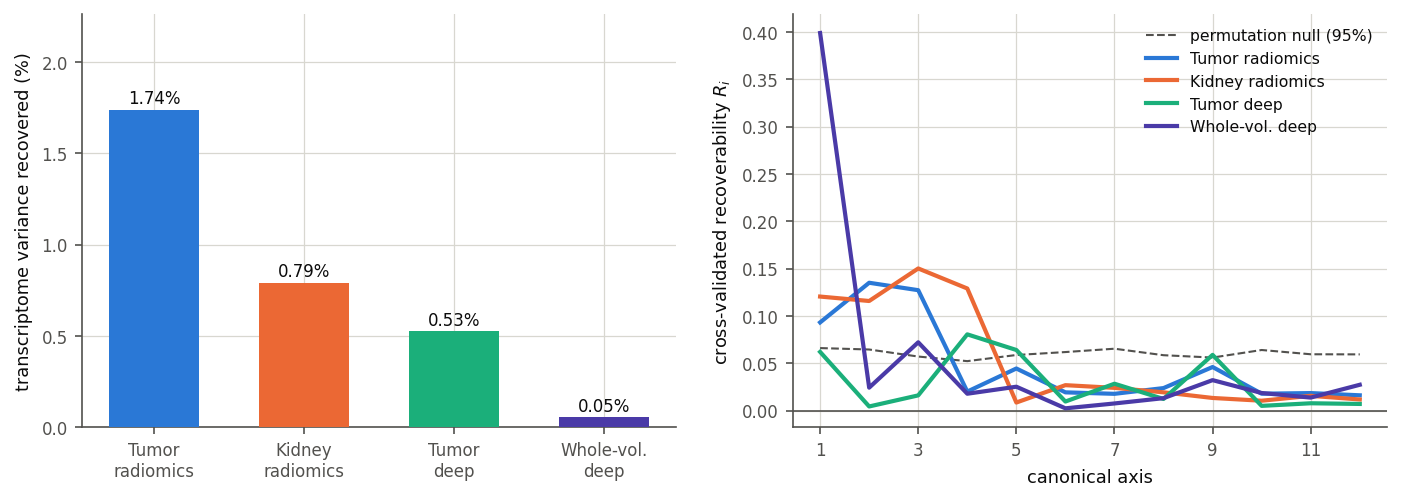

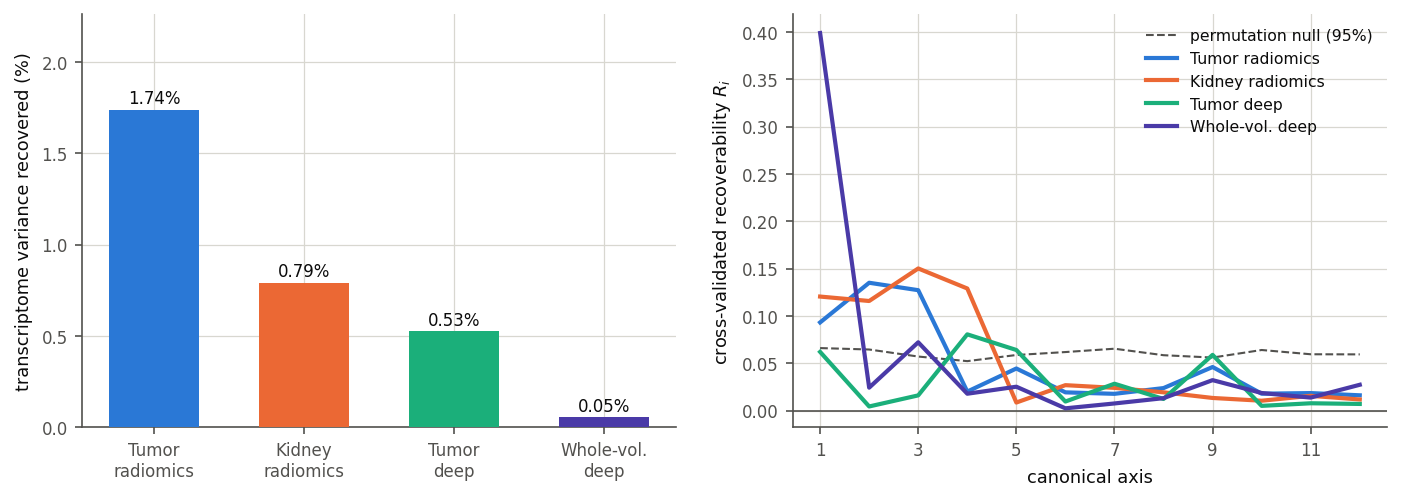

In [16]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# All-pairs CVD-validated categorical slots (blue, orange, aqua, violet). The default
# fourth slot (yellow) fails the normal-vision floor against orange when every pair is
# compared, which is the case for a four-line chart.
COLORS = {"tumor_radiomics": "#2a78d6", "organ_radiomics": "#eb6834",
          "tumor_radimagenet": "#1baf7a", "whole_radimagenet": "#4a3aa7"}
SHORT = {"tumor_radiomics": "Tumor\nradiomics", "organ_radiomics": "Kidney\nradiomics",
         "tumor_radimagenet": "Tumor\ndeep", "whole_radimagenet": "Whole-vol.\ndeep"}
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#d8d7d0"

mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.size": 8.5, "axes.labelsize": 8.5,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 7.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
})

fig, (axA, axB) = plt.subplots(1, 2, figsize=(9.4, 3.4))

# (A) total recoverable share -------------------------------------------------
tau = [100 * budget[m]["tau"] for m in IMAGING]
axA.bar(np.arange(4), tau, 0.6, color=[COLORS[m] for m in IMAGING], zorder=3)
for i, v in enumerate(tau):
    axA.annotate(f"{v:.2f}%", (i, v), textcoords="offset points", xytext=(0, 3),
                 ha="center", fontsize=8, color=INK)
axA.set_xticks(np.arange(4))
axA.set_xticklabels([SHORT[m] for m in IMAGING])
axA.set_ylabel("transcriptome variance recovered (%)")
axA.set_ylim(0, max(tau) * 1.30)

# (B) recoverability across canonical axes ------------------------------------
xs = np.arange(1, N_AXES + 1)
axB.plot(xs, np.mean([spec_null[m] for m in IMAGING], axis=0), color=MUTED, lw=1.0,
         ls="--", zorder=2, label="permutation null (95%)")
for m in IMAGING:
    axB.plot(xs, spectrum[m][:N_AXES], color=COLORS[m], lw=2.0, zorder=3,
             label=SHORT[m].replace("\n", " "))
axB.set_xlabel("canonical axis")
axB.set_ylabel(r"cross-validated recoverability $R_i$")
axB.set_xticks([1, 3, 5, 7, 9, 11])
axB.axhline(0, color=MUTED, lw=0.8)
axB.legend(frameon=False, loc="upper right")

fig.tight_layout(w_pad=2.0)
for ext in ("pdf", "png"):
    fig.savefig(ART / f"rsna_bound_figure.{ext}", bbox_inches="tight")
print("saved", ART / "rsna_bound_figure.pdf")
fig

## 9. Numbers for the abstract

In [17]:
summary = {
    "cohort": cohort,
    "working_dim": int(P_STAR),
    "n_hvg": int(N_HVG),
    "panel_size": int(len(panel_idx)),
    "n_perm": N_PERM, "n_boot": N_BOOT, "n_rand": N_RAND,
    "best_representation": best,
    "bounds": {k: {kk: vv for kk, vv in v.items() if kk != "rand_draws"}
               for k, v in bounds.items()},
    "panel": {k: {kk: vv for kk, vv in v.items() if kk != "rand_draws"}
              for k, v in panel_results.items()},
    "demo_readout": demo_readout,
    "per_gene": gene_rows,
    "budget": budget,
    "spectrum": {m: [float(x) for x in spectrum[m]] for m in IMAGING},
    "spectrum_null_q95": {m: [float(x) for x in spec_null[m]] for m in IMAGING},
}
with open(ART / "summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=float)

b = bounds[best]
print(f"cohort: n={cohort['n']}, median age {cohort['age_median']:.0f}, "
      f"{cohort['n_female']} women, {cohort['n_stage_III_IV']} stage III-IV "
      f"of {cohort['n_stage_known']} staged")
print(f"in-sample rho1^2 (best) = {b['R1_insample']:.3f} vs permutation null 95% "
      f"= {b['R1_insample_null_q95']:.3f}")
print(f"honest ceiling R1_cv = {b['R1_cv']:.3f}, 95% UCL = {b['bootstrap']['ucl95']:.3f}")
print(f"MI = {b['MI_bits']:.2f} bits (null 95% {b['MI_null_q95_bits']:.2f})")
print(f"effective rank = {b['eff_rank']}")
print(f"panel/full = {panel_results[best]['panel_over_full']:.2f}, "
      f"panel vs random p = {panel_results[best]['panel_p']:.3f}")
print(f"after demographics: {b['deconf_demo']['R1_cv']:.3f} "
      f"({100*b['deconf_demo']['R1_cv']/b['R1_cv']:.0f}% retained)")
print(f"sex AUC = {demo_readout[best]['sex_auc']:.2f}, age R2 = {demo_readout[best]['age_r2']:.2f}")
print("\ntotal recoverable share tau:")
for m in IMAGING:
    print(f"  {PRETTY[m]:32s} {100*budget[m]['tau']:.2f}%  (mean OOF R2 {budget[m]['mean_r2']:+.4f}, "
          f"null {budget[m]['null_mean']:+.4f}, p={budget[m]['p']:.3f}, best gene "
          f"{budget[m]['best_gene']} {budget[m]['max_r2']:.2f})")
print(f"\nwrote {ART / 'summary.json'}")

cohort: n=190, median age 59, 65 women, 57 stage III-IV of 154 staged
in-sample rho1^2 (best) = 0.686 vs permutation null 95% = 0.561
honest ceiling R1_cv = 0.399, 95% UCL = 0.311
MI = 2.51 bits (null 95% 2.27)
effective rank = 2
panel/full = 0.59, panel vs random p = 0.010
after demographics: 0.045 (11% retained)
sex AUC = 0.81, age R2 = -0.01

total recoverable share tau:
  Tumor radiomics                  1.74%  (mean OOF R2 +0.0000, null -0.0174, p=0.020, best gene PITX1 0.12)
  Kidney radiomics                 0.79%  (mean OOF R2 -0.0063, null -0.0142, p=0.020, best gene MIR27B 0.08)
  Tumor deep (RadImageNet)         0.53%  (mean OOF R2 -0.0060, null -0.0113, p=0.020, best gene PITX1 0.07)
  Whole-volume deep (RadImageNet)  0.05%  (mean OOF R2 -0.0113, null -0.0119, p=0.314, best gene TXLNGY 0.06)

wrote /home/jrich/Desktop/rgit-private/artifacts_rsna_bound/summary.json
